# Phase 8 — Final Evaluation

## Uncertainty-Aware Material Selection using Machine Learning

### Objective

Perform the final evaluation of the selected prediction and uncertainty
framework on the previously untouched test set.

All model-development decisions were completed using only the training and
validation data.

The test set is used in this phase only for final performance assessment.

### Final Model

The selected Random Forest configuration is:

- `n_estimators = 300`
- `max_depth = 16`
- `min_samples_split = 2`
- `min_samples_leaf = 1`
- `max_features = 1.0`
- `random_state = 42`

### Evaluation Scope

The final evaluation will assess:

1. Predictive performance on unseen test materials
2. The relationship between predictive uncertainty and test error
3. Risk–coverage behavior
4. Uncertainty-aware material selection behavior

No additional model or hyperparameter selection will be performed using
the test results.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

df = pd.read_csv(
    "../data/processed/clean_materials_data.csv"
)

X = df.drop(columns=["K_VRH"])
y = df["K_VRH"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (944, 4)
Validation: (118, 4)
Test: (119, 4)


In [2]:
numerical_features = [
    "nsites",
    "volume",
    "elastic_anisotropy"
]

categorical_features = [
    "space_group"
]

tree_preprocessor = ColumnTransformer([
    (
        "num",
        "passthrough",
        numerical_features
    ),
    (
        "cat",
        OneHotEncoder(
            handle_unknown="ignore"
        ),
        categorical_features
    )
])

final_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    (
        "regressor",
        RandomForestRegressor(
            n_estimators=300,
            max_depth=16,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=1.0,
            random_state=42,
            n_jobs=-1
        )
    )
])

final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['nsites','volume','space_group','elastic_anisotropy']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated

In [3]:
y_test_pred = final_model.predict(X_test)

test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred
    )
)

test_r2 = r2_score(
    y_test,
    y_test_pred
)

print("Final Test Performance")
print("----------------------")
print(f"MAE:  {test_mae:.2f} GPa")
print(f"RMSE: {test_rmse:.2f} GPa")
print(f"R²:   {test_r2:.3f}")

Final Test Performance
----------------------
MAE:  35.18 GPa
RMSE: 46.40 GPa
R²:   0.553


In [4]:
from scipy.stats import pearsonr, spearmanr

# Transform the untouched test set
X_test_processed = final_model[
    "preprocessor"
].transform(X_test)

rf_regressor = final_model[
    "regressor"
]

# Individual tree predictions
test_tree_predictions = np.array([
    tree.predict(X_test_processed)
    for tree in rf_regressor.estimators_
])

# Mean prediction and tree-disagreement uncertainty
test_mean_prediction = test_tree_predictions.mean(axis=0)
test_uncertainty = test_tree_predictions.std(axis=0)

# Absolute prediction error
test_absolute_error = np.abs(
    y_test.to_numpy() - test_mean_prediction
)

# Correlations
test_pearson_r, test_pearson_p = pearsonr(
    test_uncertainty,
    test_absolute_error
)

test_spearman_r, test_spearman_p = spearmanr(
    test_uncertainty,
    test_absolute_error
)

print("Final Test — Uncertainty vs Absolute Error")
print("------------------------------------------")

print(
    f"Pearson correlation:  "
    f"{test_pearson_r:.3f} "
    f"(p = {test_pearson_p:.4g})"
)

print(
    f"Spearman correlation: "
    f"{test_spearman_r:.3f} "
    f"(p = {test_spearman_p:.4g})"
)

print()
print(f"Mean uncertainty:   {test_uncertainty.mean():.2f} GPa")
print(f"Median uncertainty: {np.median(test_uncertainty):.2f} GPa")

Final Test — Uncertainty vs Absolute Error
------------------------------------------
Pearson correlation:  0.373 (p = 2.954e-05)
Spearman correlation: 0.328 (p = 0.0002721)

Mean uncertainty:   41.14 GPa
Median uncertainty: 39.66 GPa


In [5]:
test_results = pd.DataFrame({
    "actual_K_VRH": y_test.to_numpy(),
    "predicted_K_VRH": test_mean_prediction,
    "uncertainty": test_uncertainty,
    "absolute_error": test_absolute_error
})

test_sorted = (
    test_results
    .sort_values("uncertainty")
    .reset_index(drop=True)
)

coverage_levels = [
    1.00,
    0.90,
    0.80,
    0.70,
    0.60,
    0.50,
    0.40,
    0.30
]

test_risk_coverage = []

for coverage in coverage_levels:

    n_keep = int(
        np.ceil(len(test_sorted) * coverage)
    )

    retained = test_sorted.iloc[:n_keep]

    test_risk_coverage.append({
        "coverage": coverage,
        "n_materials": n_keep,
        "MAE": retained["absolute_error"].mean()
    })

test_risk_coverage = pd.DataFrame(
    test_risk_coverage
)

test_risk_coverage.round(2)

,coverage,n_materials,MAE
0,1.0,119,35.18
1,0.9,108,32.64
2,0.8,96,33.16
3,0.7,84,31.48
4,0.6,72,30.23
5,0.5,60,28.78
6,0.4,48,25.69
7,0.3,36,21.81


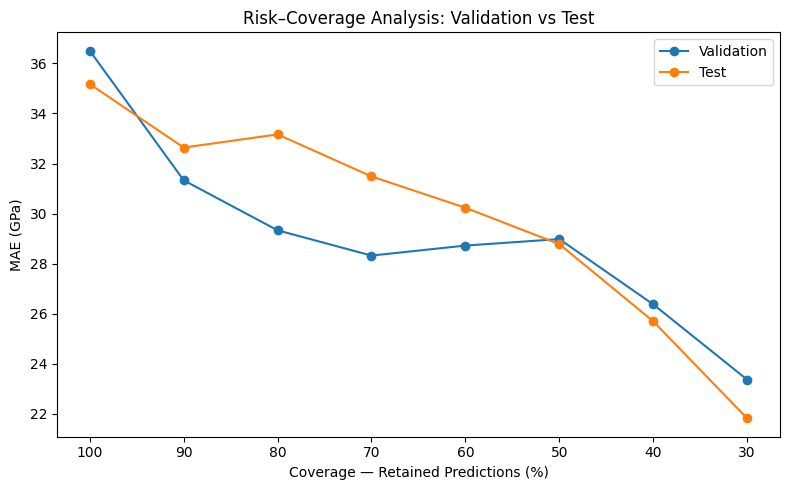

In [6]:
# Validation risk-coverage results from Phase 6
validation_coverage = pd.DataFrame({
    "coverage": [
        1.00, 0.90, 0.80, 0.70,
        0.60, 0.50, 0.40, 0.30
    ],
    "MAE": [
        36.51, 31.33, 29.33, 28.32,
        28.72, 28.98, 26.37, 23.36
    ]
})

figures_dir = Path("../outputs/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 5))

plt.plot(
    validation_coverage["coverage"] * 100,
    validation_coverage["MAE"],
    marker="o",
    label="Validation"
)

plt.plot(
    test_risk_coverage["coverage"] * 100,
    test_risk_coverage["MAE"],
    marker="o",
    label="Test"
)

plt.xlabel("Coverage — Retained Predictions (%)")
plt.ylabel("MAE (GPa)")
plt.title("Risk–Coverage Analysis: Validation vs Test")

plt.gca().invert_xaxis()
plt.legend()

plt.tight_layout()

plt.savefig(
    figures_dir / "risk_coverage_validation_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Final Evaluation Summary

The selected uncertainty-aware Random Forest framework was evaluated on the
previously untouched test set containing 119 materials.

No model selection, hyperparameter tuning, or uncertainty-method development
was performed using the test data.

### Predictive Performance

The final model achieved:

- MAE: 35.18 GPa
- RMSE: 46.40 GPa
- R²: 0.553

These results were consistent with the validation performance:

- Validation MAE: 36.51 GPa
- Validation RMSE: 50.22 GPa
- Validation R²: 0.565

The absence of a substantial validation-to-test performance degradation
supports the generalization of the selected model within the evaluated data.

### Uncertainty Validation

Random Forest tree disagreement was evaluated as an empirical uncertainty
signal on the untouched test set.

The relationship between uncertainty and absolute prediction error was:

- Pearson correlation: r = 0.373 (p < 0.001)
- Spearman correlation: ρ = 0.328 (p < 0.001)

The positive and statistically significant associations independently support
the validation-set finding that larger ensemble disagreement tends to be
associated with larger prediction errors.

Mean test uncertainty was 41.14 GPa and median uncertainty was 39.66 GPa,
closely matching the corresponding validation uncertainty distribution.

### Risk–Coverage Analysis

Materials were ranked from lowest to highest predictive uncertainty and
progressively higher-uncertainty predictions were excluded.

Test MAE changed from:

- 35.18 GPa at 100% coverage
- 33.16 GPa at 80% coverage
- 31.48 GPa at 70% coverage
- 28.78 GPa at 50% coverage
- 25.69 GPa at 40% coverage
- 21.81 GPa at 30% coverage

The relationship was not perfectly monotonic at every coverage level.
Nevertheless, the overall trend showed substantially lower prediction error
among lower-uncertainty predictions.

Restricting predictions to the lowest-uncertainty 30% reduced MAE from
35.18 GPa to 21.81 GPa, corresponding to an approximately 38% reduction.

### Final Interpretation

The results support the use of Random Forest tree disagreement as a useful
relative risk indicator for this dataset.

The uncertainty estimate is not a calibrated confidence interval and should
not be interpreted as a direct estimate of expected prediction error.
Instead, it provides an empirical signal that can support risk-aware material
screening and selection.

Combined with the Pareto-based selection framework, the project demonstrates
how predicted material performance and model uncertainty can be considered
jointly rather than ranking candidate materials solely by point predictions.

In [7]:
import joblib

models_dir = Path("../outputs/models")
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / "uncertainty_aware_random_forest.joblib"

joblib.dump(
    final_model,
    model_path
)

print(f"Model saved to: {model_path}")

Model saved to: ../outputs/models/uncertainty_aware_random_forest.joblib
